# Support Vector Machine Classifier (SVC) - Fradulent Card Data
### (adapted from from Professsor Kyle Whynott's CPSC 483 course material)

## 0. Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
import math
import joblib
import random

## 1. Framing the Problem

- What is the __business or research__ objective?

The business problem is to detect fraudulent transactions based off of credit card data using a SVM model. 

- How will they (the business or research facility) benefit from this chosen machine learning model

The business in question will benefit from this ML model because the model will classify which transactions are considered fraudulent or non-fraudulent using the data.

- What performance metrics should be used for the chosen problem?

    - [Performance Metrics by Neptune AI](https://neptune.ai/blog/performance-metrics-in-machine-learning-complete-guide)
    - [Evaluation Metrics by National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC10937649/)
    - [Evaluation Metrics by Amir Masoud](https://iamirmasoud.com/2022/06/19/understanding-micro-macro-and-weighted-averages-for-scikit-learn-metrics-in-multi-class-classification-with-example/)

We can use Precision and Recall to keep count of all of the transactions that are confirmed to be fraudulent or non-fraudulent.


*It is alright to skip step 1 for now and import and familiarize youself with the data first (**Steps** __2__ & __3__)*

## 2. Get the Data

Method for Retrieving Data from UCI ML Repo
- [UCI ML Repo Github Repository view README.md for Instructions](https://github.com/uci-ml-repo/ucimlrepo)
- [Read CSV Method from Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv)

In [3]:
df = pd.read_csv(r'C:\Users\Troy\Downloads\cpsc483_spring_2026\card_transdata.csv')

## 3. Explore the Data (Exploratory Data Analysis - EDA)

- DataFrame.head()
- DataFrame.info()
- DataFrame.describe()
- DataFrame.value_counts()

See [Pandas Documentation - Data Frame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) for more methods and information on methods already used in class.

Check out [Matplotlib's Documentation](https://matplotlib.org/stable/plot_types/index.html) for the different types of graphs that can be made to explore the data. **I highly suggest spending more time with EDA** then I do with in-class with prior examples. It is good to familiarize yourself with the data before deciding what to do with it and if it can even work for a machine learning model.

It may be useful to have Python's list slicing method to access certain columns of a dataframe, explore the dataset, and prepare the data for trainning by knowing about list slicing in Python (data frame in the context of using Dataframes via Pandas) check out this article [here](https://www.pythonmorsels.com/slicing/)

*Note: Instead of a number followed by a colon (:) (i.e. [0:4]) dataframes use the name of the data frame column to perform splicing

df - dataframe

df["Column 1"] - where "Column 1" is the name of the column to be spliced

In [4]:
# Insert Code to Explore the Data (Perform EDA Here)

display(df.head(10))
df.info()
display(df.describe())
display(df.value_counts())


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


distance_from_home  distance_from_last_transaction  ratio_to_median_purchase_price  repeat_retailer  used_chip  used_pin_number  online_order  fraud
0.004874            0.198102                        0.998148                        0.0              0.0        0.0              1.0           0.0      1
18.271839           0.558001                        0.161158                        1.0              0.0        0.0              1.0           0.0      1
18.271944           0.079844                        0.264669                        1.0              0.0        0.0              0.0           0.0      1
18.271993           1.078692                        0.712373                        1.0              0.0        0.0              1.0           0.0      1
18.272016           0.197228                        0.615863                        1.0              0.0        0.0              0.0           0.0      1
                                                                                 

## 4. Prepare the Data and Model for Machine Learning

### Data Cleaning

#### Drop (or Fill) All NaN Values from Dataset (Clean the Data)

- DataFrame.fillna()
- DataFrame.drop()
- DataFrame.dropna()


See [Pandas Documentation - Data Frame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) for more methods and information on methods already used in class. (**Same link as above for Pandas**)

*Note: Sometimes it will be necessary depending on the dataset to also use __Numpy's methods__ documentation on this can be found [here](https://numpy.org/doc/stable/index.html) ( i.e. np.unique() )*

In [5]:
# Insert Code Here

display(df.head(10))

# Select binary columns (those that are effectively 0.0 or 1.0)
binary_cols = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


- Convert all __floats__ for true or false (binary) columns to __ints__

In [6]:
# Convert them to int
df[binary_cols] = df[binary_cols].astype(int)
display(df.head(10))

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0
5,5.586408,13.261073,0.064768,1,0,0,0,0
6,3.724019,0.956838,0.278465,1,0,0,1,0
7,4.848247,0.320735,1.273050,1,0,1,0,0
8,0.876632,2.503609,1.516999,0,0,0,0,0
9,8.839047,2.970512,2.361683,1,0,0,1,0


**Hint**: In the end-end ML project example there's one column that gets converted to int, now we need to do it with all columns that represent binary values (1's and 0's)

### Balance Out the Classes (To prevent class imbalance)
* Be sure to change 'df' to whatever is the name of your dataframe

In [7]:
# Seperate the majority and minority classes
majority_class = df[df["fraud"] == 0]
minority_class = df[df["fraud"] == 1]

# Downsample the majority AND keep the minority smaller for speed
# Let's target 10,000 samples of each for a total of 20,000
n_target = 10000 

downsampled_majority = resample(majority_class, replace=False, n_samples=n_target, random_state=42)
downsampled_minority = resample(minority_class, replace=False, n_samples=n_target, random_state=42)

df = pd.concat([downsampled_majority, downsampled_minority])

### Perform Stratified Sampling and Reduce the Amount of Data to Prevent Overfitting

- Checkout [Scikit Learn's Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) to see how to create a StratifiedShuffleSplit
- Or... [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) with stratified sampling

In [8]:
# Create Train and Test Split Here (Remember to Perform Cross Fold Validation Later if Not Using a Validation Set)
from sklearn.model_selection import train_test_split

# 1. Define your features and target
X = df.drop("fraud", axis=1)
y = df["fraud"]

# 2. Perform the split
# Using 'stratify=y' ensures the 50/50 balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (16000, 7)
Testing shape: (4000, 7)


### Build the Data Pipeline

In [9]:
# Build the Data Pipeline
features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Define continuous features that need scaling
num_features = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]

# Build the Preprocessing step
preprocessing = ColumnTransformer([
    ("num_scaler", StandardScaler(), num_features)
], remainder="passthrough")

# This pipeline will be used for your actual SVM later
pipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")) 
])

### Create a Baseline Model

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = Pipeline([
    ("preprocessor", preprocessing),
    ("dummy", DummyClassifier(strategy="most_frequent"))
])

baseline_scores = cross_val_score(
    baseline, 
    X_train, 
    y_train, 
    cv=5
)

# 3. Output the mean score
print(f"Baseline Mean Accuracy: {baseline_scores.mean():.4f}")

Baseline Mean Accuracy: 0.5000


## 5. Select and Train the Model

### Create the Initial Support Vector Machine

In [11]:
# Code to Be Completed Here
from sklearn.model_selection import cross_val_score

svm_scores = cross_val_score(
    pipeline,
    X_train,
    y_train.values.ravel(),
    cv=5,
    n_jobs=-1  
)

print(f"SVM Mean Accuracy: {svm_scores.mean():.4f}")
print(f"SVM Standard Deviation: {svm_scores.std():.4f}")


SVM Mean Accuracy: 0.9826
SVM Standard Deviation: 0.0005


### Run Cross-Validation to Get the Score of the Initial ML Model

In [12]:
from sklearn.model_selection import GridSearchCV

# 1. Define the Parameter Grid
# Note: Use 'svc__' prefix to target the 'svc' step inside your pipeline
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.1], # Reduced to speed up execution
    'svc__kernel': ['rbf'] 
}

# 2. Initialize the GridSearchCV object
# Replace the placeholder string with your 'pipeline' object
grid_search = GridSearchCV(
    estimator=pipeline, # This must be the object, not a string
    param_grid=param_grid, 
    cv=3,               # 3-fold is much faster than 5-fold for large data
    scoring='average_precision', 
    n_jobs=-1,          
    verbose=3
)

# 3. Fit the grid search to the data
# This handles the scaling and the SVM search automatically
grid_search.fit(X_train, y_train)

# 4. Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score (Avg Precision):", grid_search.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best cross-validation score (Avg Precision): 0.9993654096433474


## 6. Fine Tune the Model

## Use Grid Search (or RandomSearch) CV For Hyper-Parameter Tuning

In [13]:
# Create a separate pipeline for PCA visualization
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Project the high-dimensional data down to 2 dimensions
X_train_scaled_pca = pca_pipeline.fit_transform(X_train)

# Extract loadings to see which features contribute most to the PCs
pca_step = pca_pipeline.named_steps['pca']
loadings_df = pd.DataFrame(
    data=pca_step.components_, 
    columns=X_train.columns, 
    index=['PC1', 'PC2']
)
display(loadings_df)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
PC1,0.659449,-0.017338,-0.178418,0.555435,-0.383183,-0.112231,0.255069
PC2,-0.089047,-0.031595,0.656947,-0.008183,0.056639,-0.456882,0.589472


### Build Standardized PCA Pipe-line to Visualize the Multi-Dimensional Data (To Visualize SVM)

In [14]:
pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])
X_train_scaled_pca = pipeline.fit_transform(X_train)

In [15]:
pca_pipeline_step = pipeline.named_steps['pca']
loadings = pca_pipeline_step.components_
loadings_df = pd.DataFrame(data=loadings, columns=X_train.columns, index=[f'PC{i+1}' for i in range(pca_pipeline_step.n_components)])
display(loadings_df)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
PC1,0.659449,-0.017338,-0.178418,0.555435,-0.383183,-0.112231,0.255069
PC2,-0.089047,-0.031595,0.656947,-0.008183,0.056639,-0.456882,0.589472


### Plotting the Initial Scalble Vectore Machine Classifier (SVC)

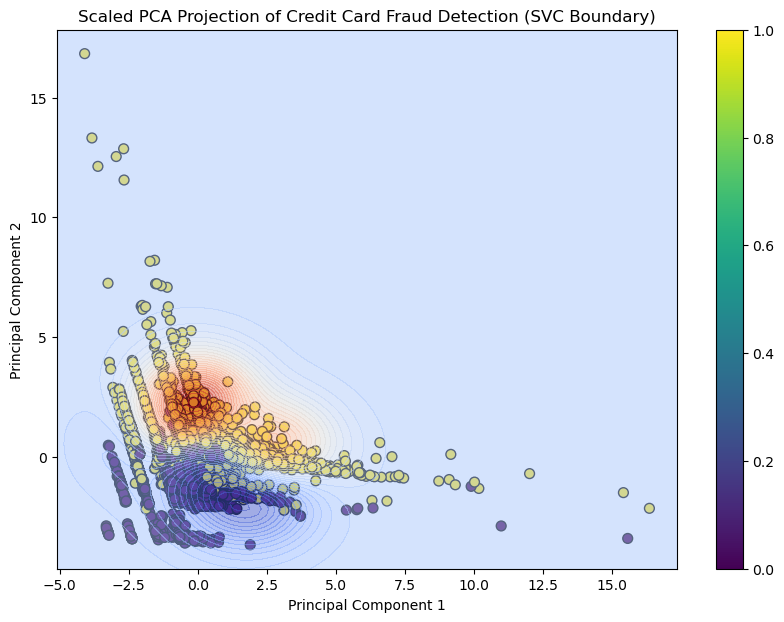

In [24]:
# Make sure you plot a decision boundary
# Assuming model_svc is your trained SVC model
# and X_train_scaled_pca is your PCA transformed data

plt.figure(figsize=(10, 7))

# 2. Scatter plot of the data points
scatter = plt.scatter(
    X_train_scaled_pca[:, 0], 
    X_train_scaled_pca[:, 1], 
    c=y_train, 
    cmap="viridis", 
    edgecolor='k', 
    s=50
)

# Plot the decision boundary
# Create a grid of points to evaluate the model
x_min, x_max = X_train_scaled_pca[:, 0].min() -1, X_train_scaled_pca[:, 0].max() + 1
y_min, y_max = X_train_scaled_pca[:, 1].min() -1, X_train_scaled_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = grid_search.best_estimator_.named_steps['svc'].decision_function(
    pca_pipeline.named_steps['pca'].inverse_transform(np.c_[xx.ravel(), yy.ravel()])
)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scaled PCA Projection of Credit Card Fraud Detection (SVC Boundary)")
plt.colorbar(scatter)
plt.show()

### Re-fine through Feature Selection

#### Evaluating feature importance


In [29]:
from sklearn.inspection import permutation_importance

results = permutation_importance(
    grid_search.best_estimator_, 
    X_test, 
    y_test, 
    n_repeats=5, 
    random_state=42,
)

#### Displaying importance


In [30]:
importances = results.importances_mean
print(importances)

[0.1032  0.0453  0.3195  0.01765 0.0406  0.03305 0.10585]


#### Select Features that are Relevant Based on Importances

In [31]:
threshold = np.median(importances)
indices = np.where(importances > threshold)[0]
# new x_train and y_train_data
X_train_new_feature = X_train.iloc[:, indices]
X_test_new_feature = X_test.iloc[:, indices]

### Make Finanlized Classifier with Newly Hypertuned Parameters and Refined Feature Selection

In [32]:
# Code to Be Completed Here!!! (Bonus pts part 1, +5 pts)

new_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num_scaler", StandardScaler(), X_train_new_feature.columns)
    ], remainder="passthrough")),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Perform cross-validation with the new pipeline
new_svm_scores = cross_val_score(
    new_pipeline,
    X_train_new_feature,
    y_train.values.ravel(),
    cv=5,
    n_jobs=-1
)

print(f"New SVM Mean Accuracy: {new_svm_scores.mean():.4f}")
print(f"New SVM Standard Deviation: {new_svm_scores.std():.4f}")


New SVM Mean Accuracy: 0.9313
New SVM Standard Deviation: 0.0061


### Evaluate the Final Model on the Test Set

In [36]:
#Code to Be Completed Here !!! (Bonus pts part 2, +5 pts)

# Evaluate the final model on the test set
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2000
           1       0.98      1.00      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



### Build Standardized PCA Pipe-line to Visualize the Multi-Dimensional Data

In [38]:
# 1. Define the final model pipeline
# We include PCA here so the model 'learns' on the 2D projection

X_final_training_set = X_train_new_feature

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('svc', SVC(kernel="rbf", C=1.0, gamma="scale")) # Use your best params here
])

# 2. Fit the model to the training set with reduced features
final_model.fit(X_final_training_set, y_train)

# Use the pipeline to predict directly on the test features
y_test_pred = final_model.predict(X_test_new_feature)

# Print the evaluation
print("Final Model Classification Report:")
print(classification_report(y_test, y_test_pred))

# Slice the pipeline to get only the scaler and pca steps [0 and 1]
# Then use .transform() to get the 2D coordinates
X_final_train_scaled_pca = final_model[:-1].transform(X_final_training_set)
X_final_test_scaled_pca = final_model[:-1].transform(X_test_new_feature)

# Verify the shape - should be (n_samples, 2)
print(f"PCA shape: {X_final_test_scaled_pca.shape}")

Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2000
           1       0.93      0.91      0.92      2000

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000

PCA shape: (4000, 2)


In [39]:
pca_pipeline_step = final_model.named_steps['pca']
loadings = pca_pipeline_step.components_
columns = ["distance_from_home","ratio_to_median_purchase_price","online_order"]
loadings_df = pd.DataFrame(data=loadings, columns=columns, index=[f'PC{i+1}' for i in range(pca_pipeline_step.n_components)])
display(loadings_df)

,distance_from_home,ratio_to_median_purchase_price,online_order
PC1,-0.224445,0.741379,0.632441
PC2,0.858720,-0.156337,0.488015


### Final Scalable Vectore Machine Classifier (SVC)

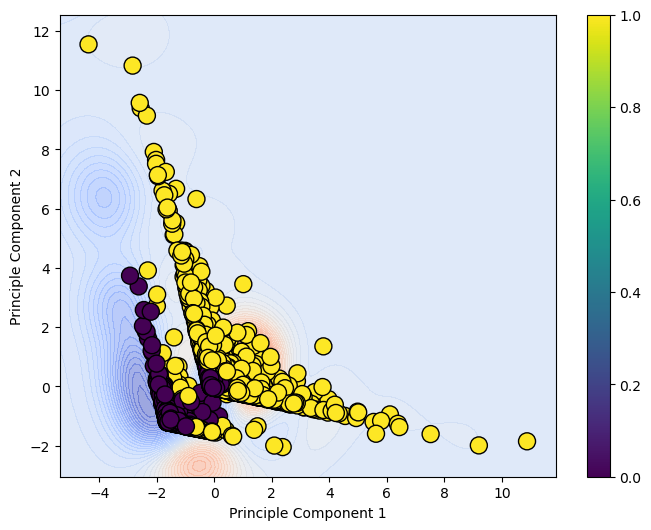

In [42]:
# 1. Create meshgrid based on the PCA projected data (X_final_test_scaled_pca)
x_min, x_max = X_final_test_scaled_pca[:, 0].min() - 1, X_final_test_scaled_pca[:, 0].max() + 1
y_min, y_max = X_final_test_scaled_pca[:, 1].min() - 1, X_final_test_scaled_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), 
                     np.linspace(y_min, y_max, 100))

# 2. Use the meshgrid directly to compute decisions (2 features)
Z = final_model.named_steps['svc'].decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.5)
scatter = plt.scatter(X_final_test_scaled_pca[:,0], X_final_test_scaled_pca[:,1], 
                      c=y_test_pred, cmap="viridis", edgecolor='k', s=150)
plt.colorbar(scatter)
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()


In [43]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
class_names = ['Not Fraud', 'Fraud']
class_report = classification_report(y_test, y_test_pred, target_names=class_names)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Confusion Matrix:
 [[1867  133]
 [ 182 1818]]
Classification Report:
               precision    recall  f1-score   support

   Not Fraud       0.91      0.93      0.92      2000
       Fraud       0.93      0.91      0.92      2000

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000



### Plot the Final Confusion matrix

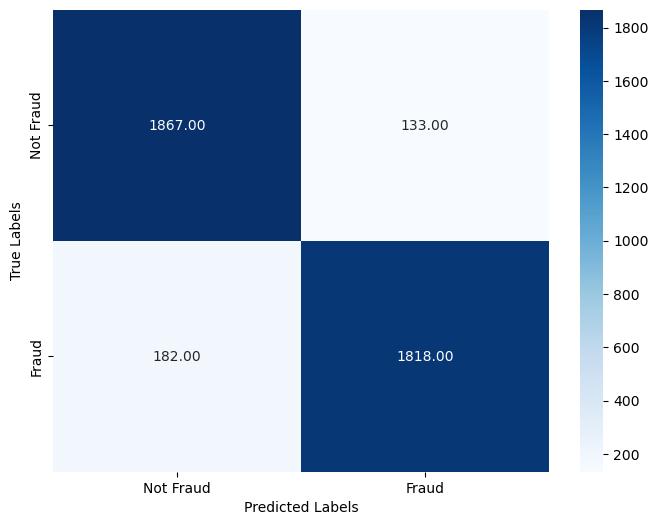

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### Plot the Final Classification Report

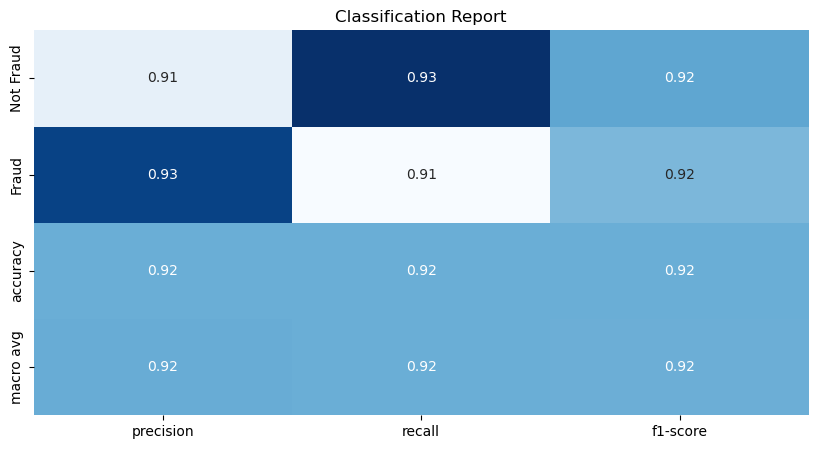

In [45]:
class_report = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True)
df_final_report = pd.DataFrame(class_report).transpose()
plt.figure(figsize=(10, 5))
sns.heatmap(df_final_report.iloc[:-1, :].drop(columns=['support']), annot=True, cmap='Blues', cbar=False)
plt.title('Classification Report')
plt.show()

### Plot and Get the Final Percision-Recall Score

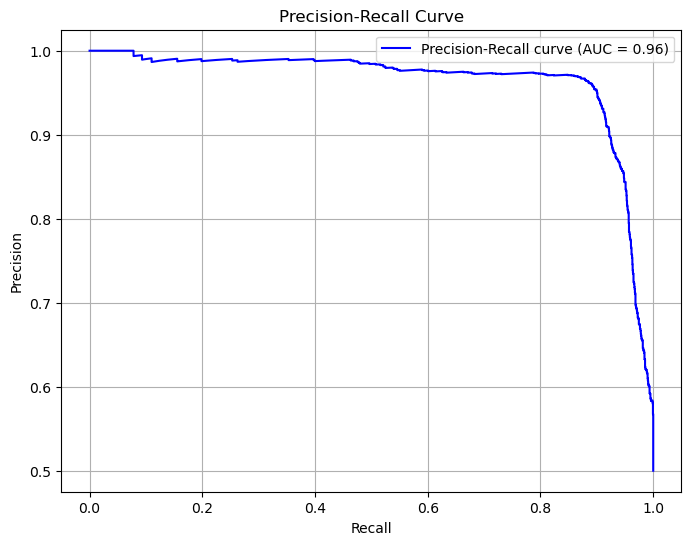

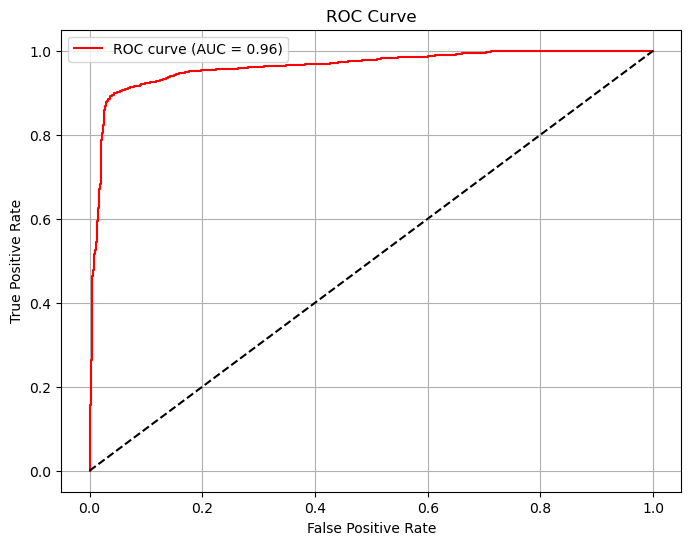

In [59]:
# Getting the predicted probabilities for the positive class (fraud)
# Pass raw data through the whole pipeline

X_test_raw = X_test_new_feature  # Use the new feature set
y_scores = final_model.decision_function(X_test_raw)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {
pr_auc:.2f})', color="blue")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()

# Plot ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color="red")
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.legend()
plt.show()


### Saving the Created Model for 'Live' Testing

In [54]:
joblib.dump('''SVM Fraud Classifier''', "model_name.pkl")

['model_name.pkl']